#**Task 1: Tải và Tiền xử lý Dữ liệu**

In [2]:
!tar xzvf UD_English-EWT.tar.gz

UD_English-EWT/
UD_English-EWT/en_ewt-ud-test.txt
UD_English-EWT/en_ewt-ud-train.txt
UD_English-EWT/README.md
UD_English-EWT/LICENSE.txt
UD_English-EWT/stats.xml
UD_English-EWT/en_ewt-ud-train.conllu
UD_English-EWT/en_ewt-ud-dev.txt
UD_English-EWT/en_ewt-ud-dev.conllu
UD_English-EWT/en_ewt-ud-test.conllu


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import requests
import os
from collections import defaultdict
import numpy as np

TRAIN_FILE = "UD_English-EWT/en_ewt-ud-train.conllu"
DEV_FILE = "UD_English-EWT/en_ewt-ud-dev.conllu"

# 1. Viết hàm đọc file .conllu
def load_conllu(file_path):
    """
    Đọc file .conllu và trả về danh sách các câu.
    Mỗi câu là một danh sách các cặp (word, upos_tag).
    """
    sentences = []
    current_sentence = []

    # Kiểm tra xem file có tồn tại không
    if not os.path.exists(file_path):
        print(f"Lỗi: Không tìm thấy tệp tại {file_path}")
        return []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue

            if line.startswith('#'):
                continue

            parts = line.split('\t')

            if '-' in parts[0] or '.' in parts[0]:
                continue

            if len(parts) > 3: # Đảm bảo dòng có đủ cột
                word = parts[1]
                upos_tag = parts[3]
                if upos_tag:
                    current_sentence.append((word, upos_tag))

    if current_sentence:
        sentences.append(current_sentence)

    return sentences

# 1.1. Đọc dữ liệu
train_data = load_conllu(TRAIN_FILE)
dev_data = load_conllu(DEV_FILE)

print(f"Đã tải {len(train_data)} câu huấn luyện.")
print(f"Đã tải {len(dev_data)} câu phát triển.")
if train_data:
    print(f"Ví dụ (5 token đầu tiên): {train_data[0][:5]}")

# 2. Xây dựng Từ điển (Vocabulary)
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

# <PAD> luôn là index 0
word_to_ix = {PAD_TOKEN: 0, UNK_TOKEN: 1}
tag_to_ix = {PAD_TOKEN: 0} # Nhãn padding cũng là 0

word_counts = defaultdict(int)
tag_set = set()

for sentence in train_data:
    for word, tag in sentence:
        word_counts[word] += 1
        tag_set.add(tag)

current_word_idx = 2 # 0 là PAD, 1 là UNK
for word, count in word_counts.items():
    if count > 1: # Chỉ thêm từ xuất hiện > 1 lần
        if word not in word_to_ix:
            word_to_ix[word] = current_word_idx
            current_word_idx += 1

current_tag_idx = 1 # 0 là PAD
for tag in sorted(list(tag_set)):
    if tag not in tag_to_ix:
        tag_to_ix[tag] = current_tag_idx
        current_tag_idx += 1

# Từ điển map ngược để dự đoán
ix_to_tag = {idx: tag for tag, idx in tag_to_ix.items()}

# Hằng số global cho padding và unknown
PAD_IDX = word_to_ix[PAD_TOKEN]
UNK_IDX = word_to_ix[UNK_TOKEN]


print(f"Kích thước từ điển từ (word_to_ix): {len(word_to_ix)}")
print(f"Kích thước từ điển nhãn (tag_to_ix): {len(tag_to_ix)}")

Đã tải 12544 câu huấn luyện.
Đã tải 2001 câu phát triển.
Ví dụ (5 token đầu tiên): [('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ')]
Kích thước từ điển từ (word_to_ix): 9875
Kích thước từ điển nhãn (tag_to_ix): 18


#**Task 2: Tạo PyTorch Dataset và DataLoader**

In [4]:
# 1. Tạo lớp POSDataset
class POSDataset(Dataset):
    def __init__(self, data, word_to_ix, tag_to_ix):
        self.sentences = data
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix
        self.unk_idx = word_to_ix[UNK_TOKEN]
        self.pad_idx = tag_to_ix[PAD_TOKEN] # Dùng cho tag

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]

        sentence_indices = []
        tag_indices = []

        for word, tag in sentence:
            word_idx = self.word_to_ix.get(word, self.unk_idx)
            sentence_indices.append(word_idx)

            tag_idx = self.tag_to_ix.get(tag, self.pad_idx)
            tag_indices.append(tag_idx)

        return torch.tensor(sentence_indices, dtype=torch.long), \
               torch.tensor(tag_indices, dtype=torch.long)

# 2. Viết hàm collate_fn để đệm (pad)
def collate_fn_pad(batch):
    """
    Hàm collate_fn để đệm (pad) các câu trong batch.
    """
    sentences = [item[0] for item in batch]
    tags = [item[1] for item in batch]

    # pad_sequence dùng padding_value=0 (PAD_IDX) theo mặc định
    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=PAD_IDX)
    padded_tags = pad_sequence(tags, batch_first=True, padding_value=PAD_IDX)

    return padded_sentences, padded_tags

# 3. Khởi tạo Dataset và DataLoader
train_dataset = POSDataset(train_data, word_to_ix, tag_to_ix)
dev_dataset = POSDataset(dev_data, word_to_ix, tag_to_ix)

BATCH_SIZE = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn_pad
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_pad
)

# Kiểm tra một batch
print("Kiểm tra DataLoader:")
try:
    sample_sentences, sample_tags = next(iter(train_loader))
    print(f"Kích thước batch câu (Sentences shape): {sample_sentences.shape}")
    print(f"Kích thước batch nhãn (Tags shape): {sample_tags.shape}")
except StopIteration:
    print("DataLoader rỗng (có thể do train_data rỗng).")

Kiểm tra DataLoader:
Kích thước batch câu (Sentences shape): torch.Size([32, 70])
Kích thước batch nhãn (Tags shape): torch.Size([32, 70])


# **Task 3: Xây dựng Mô hình RNN**

In [5]:
class SimpleRNNForTokenClassification(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, tagset_size, padding_idx=0):
        super(SimpleRNNForTokenClassification, self).__init__()

        self.tagset_size = tagset_size # Cần dùng ở Task 4

        # 1. Lớp Embedding
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx
        )

        # 2. Lớp RNN
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            batch_first=True # Quan trọng
        )

        # 3. Lớp Linear (Fully Connected)
        self.fc = nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence_indices):
        # sentence_indices: (batch_size, seq_len)

        # 1. Embedding
        # embeds: (batch_size, seq_len, embedding_dim)
        embeds = self.embedding(sentence_indices)

        # 2. RNN
        # rnn_out: (batch_size, seq_len, hidden_dim)
        rnn_out, _ = self.rnn(embeds)

        # 3. Linear
        # logits: (batch_size, seq_len, tagset_size)
        logits = self.fc(rnn_out)

        return logits

# **Task 4: Huấn luyện Mô hình**

In [20]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/pos_tagging_experiment')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# 1. Khởi tạo Hyperparameters
VOCAB_SIZE = len(word_to_ix)
TAGSET_SIZE = len(tag_to_ix)
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
EPOCHS = 20
LR = 0.001

# 2. Khởi tạo mô hình
model = SimpleRNNForTokenClassification(
    VOCAB_SIZE,
    EMBEDDING_DIM,
    HIDDEN_DIM,
    TAGSET_SIZE,
    padding_idx=PAD_IDX
).to(device)

# 3. Khởi tạo Loss và Optimizer
# ignore_index=PAD_IDX (tức là 0) là mấu chốt!
loss_function = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Mô hình đã được tạo và chuyển sang {device}.")
print(f"Mô hình có {sum(p.numel() for p in model.parameters() if p.requires_grad):,} tham số có thể huấn luyện.")

Sử dụng thiết bị: cuda
Mô hình đã được tạo và chuyển sang cuda.
Mô hình có 999,294 tham số có thể huấn luyện.


# **Task 5: Đánh giá Mô hình**

In [9]:
def evaluate(model, loader, loss_function, pad_idx, device):
    model.eval() # Chuyển mô hình sang chế độ đánh giá

    total_loss = 0.0
    correct_preds = 0
    total_tokens = 0

    with torch.no_grad(): # Tắt tính toán gradient
        for sentences, tags in loader:
            sentences, tags = sentences.to(device), tags.to(device)

            # Forward pass
            logits = model(sentences)

            # Tính loss
            loss = loss_function(logits.view(-1, model.tagset_size), tags.view(-1))
            total_loss += loss.item()

            # Tính accuracy
            preds = torch.argmax(logits, dim=2)

            # Tạo mask để BỎ QUA các token padding
            mask = (tags != pad_idx)

            correct_preds += (preds[mask] == tags[mask]).sum().item()
            total_tokens += mask.sum().item()

    avg_loss = total_loss / len(loader)
    # total_tokens có thể là 0 nếu loader rỗng
    accuracy = (correct_preds / total_tokens) if total_tokens > 0 else 0
    return avg_loss, accuracy

# **Báo cáo kết quả**:

In [21]:
# Khởi tạo các danh sách (nếu bạn vẫn muốn vẽ matplotlib)
train_loss_history = []
train_acc_history = []
dev_loss_history = []
dev_acc_history = []

best_dev_acc = 0.0
BEST_MODEL_PATH = "best_model.pth"
best_epoch = 0

# --- THÊM BIẾN NÀY ---
global_step = 0 # Biến đếm tổng số batch đã huấn luyện

print("--- Bắt đầu Huấn luyện & Đánh giá (với TensorBoard) ---")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for i, (sentences, tags) in enumerate(train_loader):
        sentences, tags = sentences.to(device), tags.to(device)
        optimizer.zero_grad()
        logits = model(sentences)
        loss = loss_function(logits.view(-1, model.tagset_size), tags.view(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        # --- THÊM VÀO ĐÂY ---
        # Ghi lại loss của TỪNG BATCH (step)
        if i % 10 == 0: # Ghi log sau mỗi 10 batch
            writer.add_scalar('Loss/train_batch', loss.item(), global_step)
        global_step += 1
        # --------------------

    avg_train_loss = epoch_loss / len(train_loader)

    # === Đánh giá ===
    train_loss_eval, train_acc = evaluate(model, train_loader, loss_function, PAD_IDX, device)
    dev_loss, dev_acc = evaluate(model, dev_loader, loss_function, PAD_IDX, device)

    # --- THÊM VÀO ĐÂY ---
    # Ghi lại kết quả (loss/acc) SAU MỖI EPOCH
    writer.add_scalar('Loss/train_epoch', avg_train_loss, epoch)
    writer.add_scalar('Accuracy/train_epoch', train_acc, epoch)
    writer.add_scalar('Loss/dev_epoch', dev_loss, epoch)
    writer.add_scalar('Accuracy/dev_epoch', dev_acc, epoch)
    # --------------------

    # (Lưu các biến cho matplotlib nếu muốn)
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_acc)
    dev_loss_history.append(dev_loss)
    dev_acc_history.append(dev_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f} | Dev Acc: {dev_acc*100:.2f}%")

    if dev_acc > best_dev_acc:
        best_dev_acc = dev_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), BEST_MODEL_PATH)

print("Training finished.")
writer.close() # Đóng writer lại

--- Bắt đầu Huấn luyện & Đánh giá (với TensorBoard) ---
Epoch 1/20 - Train Loss: 1.2471 | Dev Acc: 74.75%
Epoch 2/20 - Train Loss: 0.6424 | Dev Acc: 80.83%
Epoch 3/20 - Train Loss: 0.4740 | Dev Acc: 83.15%
Epoch 4/20 - Train Loss: 0.3798 | Dev Acc: 85.72%
Epoch 5/20 - Train Loss: 0.3180 | Dev Acc: 85.77%
Epoch 6/20 - Train Loss: 0.2745 | Dev Acc: 86.41%
Epoch 7/20 - Train Loss: 0.2434 | Dev Acc: 87.51%
Epoch 8/20 - Train Loss: 0.2196 | Dev Acc: 88.02%
Epoch 9/20 - Train Loss: 0.2009 | Dev Acc: 88.58%
Epoch 10/20 - Train Loss: 0.1863 | Dev Acc: 88.54%
Epoch 11/20 - Train Loss: 0.1736 | Dev Acc: 88.33%
Epoch 12/20 - Train Loss: 0.1628 | Dev Acc: 88.51%
Epoch 13/20 - Train Loss: 0.1540 | Dev Acc: 88.44%
Epoch 14/20 - Train Loss: 0.1446 | Dev Acc: 87.92%
Epoch 15/20 - Train Loss: 0.1361 | Dev Acc: 87.86%
Epoch 16/20 - Train Loss: 0.1290 | Dev Acc: 88.49%
Epoch 17/20 - Train Loss: 0.1220 | Dev Acc: 88.09%
Epoch 18/20 - Train Loss: 0.1153 | Dev Acc: 87.79%
Epoch 19/20 - Train Loss: 0.1095 | 

In [24]:
import torch

# --- Giả định các biến này đã tồn tại ---
# model: Đối tượng mô hình (phải cùng kiến trúc)
# BEST_MODEL_PATH: Đường dẫn đến file .pth đã lưu (ví dụ: "best_model.pth")
# best_epoch: Epoch (chỉ để in ra)
# evaluate: Hàm đánh giá đã định nghĩa
# dev_loader: DataLoader cho tập dev
# loss_function: Hàm loss đã định nghĩa
# PAD_IDX: Chỉ số padding
# device: Thiết bị (cpu/cuda)
# ----------------------------------------

try:
    # Tải trọng số của mô hình tốt nhất đã lưu
    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    # print(f"\n--- Đã tải mô hình tốt nhất (từ Epoch {best_epoch}) ---")
    print(f"\n--- Đã tải mô hình tốt nhất đã lưu tại {BEST_MODEL_PATH} ---")


    # Chạy đánh giá cuối cùng trên tập Dev
    final_dev_loss, final_dev_acc = evaluate(model, dev_loader, loss_function, PAD_IDX, device)

    print("\n--- Kết quả Cuối cùng (trên mô hình tốt nhất) ---")
    print(f"Độ chính xác CUỐI CÙNG trên tập Dev: {final_dev_acc*100:.2f}%")
    print(f"Loss cuối cùng trên tập Dev: {final_dev_loss:.4f}")

except FileNotFoundError:
    print(f"\nLỗi: Không tìm thấy file mô hình tại '{BEST_MODEL_PATH}'.")
    print("Hãy đảm bảo vòng lặp huấn luyện đã chạy và lưu mô hình.")
except Exception as e:
    print(f"\nĐã xảy ra lỗi khi tải mô hình: {e}")


--- Đã tải mô hình tốt nhất đã lưu tại best_model.pth ---

--- Kết quả Cuối cùng (trên mô hình tốt nhất) ---
Độ chính xác CUỐI CÙNG trên tập Dev: 88.58%
Loss cuối cùng trên tập Dev: 0.3637


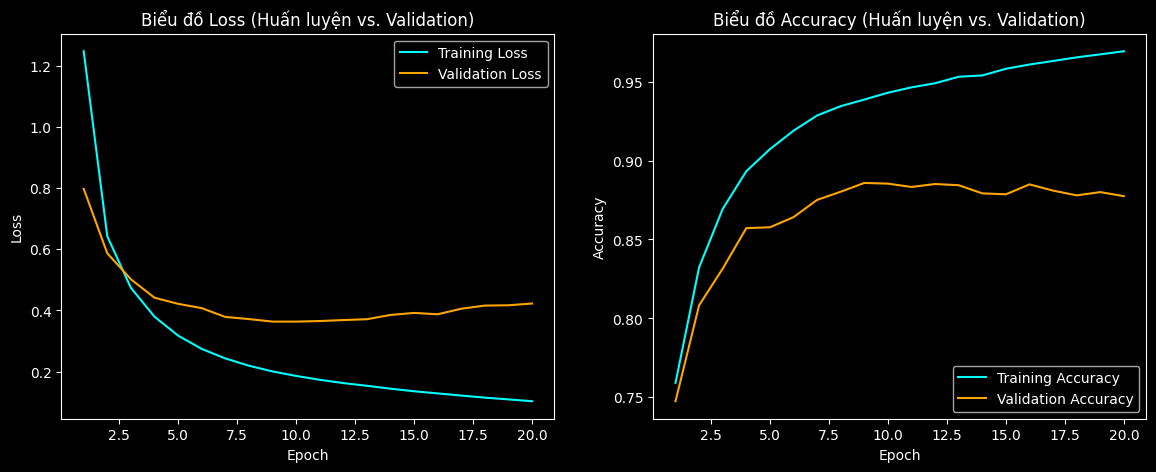

In [22]:
# Chạy cell này ngay sau cell vẽ matplotlib

plt.style.use('dark_background') # Chuyển sang nền tối

# --- Lặp lại code vẽ ---
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss', color='cyan') # Đổi màu
plt.plot(epochs_range, dev_loss_history, label='Validation Loss', color='orange') # Đổi màu
plt.legend(loc='upper right')
plt.title('Biểu đồ Loss (Huấn luyện vs. Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Biểu đồ 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label='Training Accuracy', color='cyan')
plt.plot(epochs_range, dev_acc_history, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Biểu đồ Accuracy (Huấn luyện vs. Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

# **Dự đoán câu**

In [23]:
def predict_sentence(sentence_str, model, word_to_ix, ix_to_tag, device):
    model.eval() # Đảm bảo mô hình ở chế độ eval

    # Tách từ
    words = sentence_str.split()

    # Chuyển từ sang chỉ số
    indices = [word_to_ix.get(w, UNK_IDX) for w in words]

    # Chuyển sang tensor và thêm batch dimension (batch_size=1)
    sentence_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        # (1, seq_len, tagset_size)
        logits = model(sentence_tensor)

        # (1, seq_len)
        preds_indices = torch.argmax(logits, dim=2)

        # Bỏ batch dimension và chuyển về CPU
        preds_indices = preds_indices.squeeze(0).cpu().numpy()

    # Chuyển chỉ số nhãn về tên nhãn
    tags = [ix_to_tag.get(idx, PAD_TOKEN) for idx in preds_indices]

    return list(zip(words, tags))

# Thử dự đoán
test_sentence = "I love NLP"

print(f"Đầu vào: '{test_sentence}'")
print(f"Đầu ra: {predict_sentence(test_sentence, model, word_to_ix, ix_to_tag, device)}")

Đầu vào: 'I love NLP'
Đầu ra: [('I', 'PRON'), ('love', 'VERB'), ('NLP', 'PROPN')]


# **KẾT QUẢ THỰC HIỆN**

• Độ chính xác trên tập dev: 0.8858

• Ví dụ dự đoán câu mới:
 * Câu: “I love NLP”
 * Dự đoán: [('I', 'PRON'), ('love', 'VERB'), ('NLP', 'PROPN')]